# 05 Data Visualization

Statistical tables and numerical summaries are useful, but visualizations often reveal patterns that are difficult to notice from numbers alone.

This chapter introduces four fundamental statistical graphics:

- Histogram
- Box Plot
- Scatter Plot
- Bar Chart

The goal is not simply to draw charts, but to learn **which chart to use and what statistical information it communicates**.

## Learning Objectives

After completing this chapter, you will be able to:

- choose an appropriate chart for a statistical question;
- visualize the distribution of a quantitative variable;
- identify center, spread, skewness, and potential outliers visually;
- compare categories or groups with a bar chart;
- explore relationships between two quantitative variables with a scatter plot;
- avoid common mistakes when interpreting visualizations.

## Choosing a Visualization

Different charts answer different questions.

| Chart | Main purpose | Typical variables |
|---|---|---|
| Histogram | Examine a distribution | One quantitative variable |
| Box Plot | Examine center, spread, and outliers | Quantitative variable, optionally by group |
| Bar Chart | Compare categories | One categorical variable + counts/summary |
| Scatter Plot | Examine a relationship | Two quantitative variables |

A visualization should be selected based on the **type of variables** and the **question being asked**.

## Sample Dataset

This chapter uses a fictional socioeconomic dataset containing 32 countries.

| Variable | Type | Meaning |
|---|---|---|
| `country_id` | Categorical | Fictional country identifier |
| `region` | Categorical | Fictional regional group |
| `population_million` | Quantitative | Population in millions |
| `median_age` | Quantitative | Median age |
| `gdp_per_capita_usd` | Quantitative | GDP per capita in USD |
| `life_expectancy` | Quantitative | Life expectancy in years |

The values are synthetic and are intended only for statistical education.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
current_dir = Path.cwd().resolve()
project_root = next(
    (p for p in [current_dir, *current_dir.parents] if (p / "data").is_dir()),
    None,
)

if project_root is None:
    raise FileNotFoundError("Could not find the project root containing data/.")

data_path = project_root / "data" / "05_data_visualization.csv"

print(f"Data path: {data_path}")

Data path: E:\Analytics\Statistical-Analytics\data\05_data_visualization.csv


In [14]:
df = pd.read_csv(data_path)
df.head()

,country_id,region,population_million,median_age,gdp_per_capita_usd,life_expectancy
0,Country_01,Region_A,8.2,48,62000,82.1
1,Country_02,Region_A,6.5,42,54000,80.4
2,Country_03,Region_A,12.0,39,47000,79.8
3,Country_04,Region_A,4.1,51,68000,83.0
4,Country_05,Region_A,15.4,36,43000,78.9


## Inspect the Dataset

In [15]:
print(f"Observations: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Observations: 32
Variables: 6

Data types:
country_id             object
region                 object
population_million    float64
median_age              int64
gdp_per_capita_usd      int64
life_expectancy       float64
dtype: object

Missing values:
country_id            0
region                0
population_million    0
median_age            0
gdp_per_capita_usd    0
life_expectancy       0
dtype: int64


## 1. Histogram — Understanding a Distribution

A histogram divides a quantitative variable into intervals and shows how many observations fall into each interval.

It can help us examine:

- where observations are concentrated;
- how widely they are spread;
- whether the distribution appears symmetric or skewed;
- whether there are unusual gaps or extreme values.

Unlike a bar chart, histogram bars represent adjacent numerical intervals.

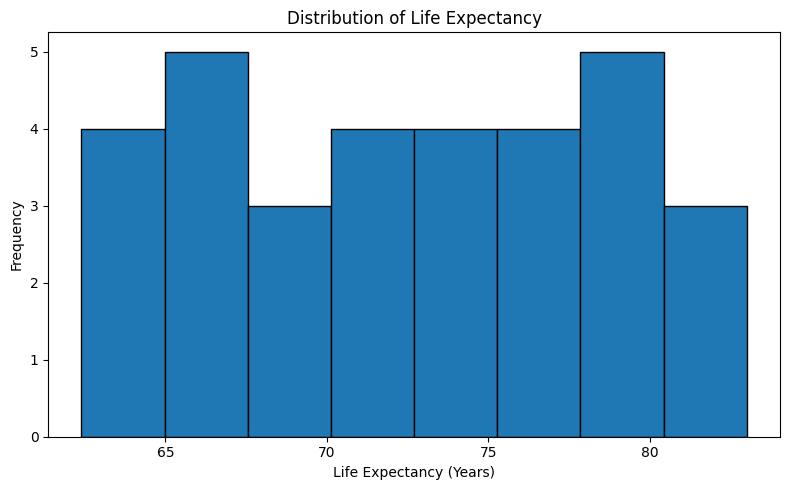

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["life_expectancy"],
    bins=8,
    edgecolor="black",
)

plt.title("Distribution of Life Expectancy")
plt.xlabel("Life Expectancy (Years)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Interpretation

Look for the **shape** rather than only the height of individual bars.

Ask:

- Where is the center of the distribution?
- How wide is the distribution?
- Does one side extend farther than the other?
- Would changing the number of bins change your visual impression?

## 2. Box Plot — Center, Spread, and Potential Outliers

A box plot summarizes a quantitative distribution using quartiles.

The box represents the interquartile range (IQR), while the line inside the box represents the median.

Potential outliers may appear beyond the whiskers.

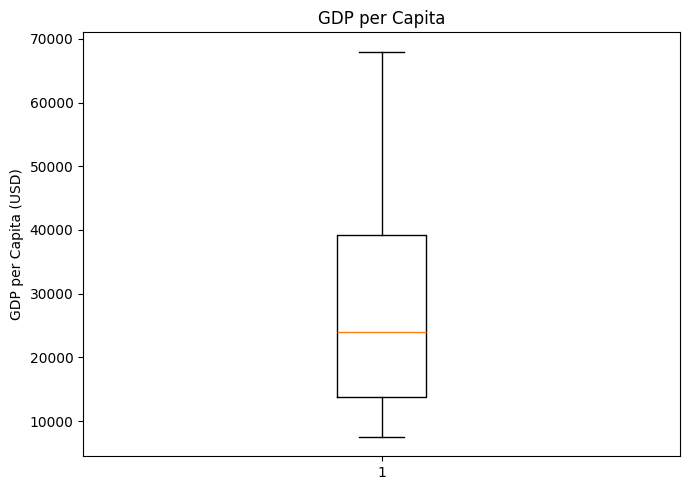

In [17]:
plt.figure(figsize=(7, 5))

plt.boxplot(df["gdp_per_capita_usd"])

plt.title("GDP per Capita")
plt.ylabel("GDP per Capita (USD)")
plt.tight_layout()
plt.show()

### Box Plots by Region

Box plots become especially useful when we want to compare the distributions of the same quantitative variable across groups.

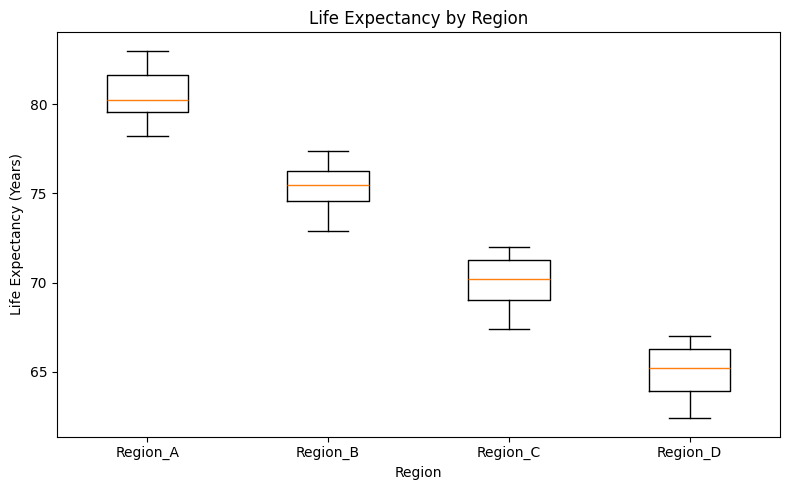

In [18]:
regions = sorted(df["region"].unique())
region_data = [
    df.loc[df["region"] == region, "life_expectancy"]
    for region in regions
]

plt.figure(figsize=(8, 5))

plt.boxplot(region_data, tick_labels=regions)

plt.title("Life Expectancy by Region")
plt.xlabel("Region")
plt.ylabel("Life Expectancy (Years)")
plt.tight_layout()
plt.show()

## 3. Bar Chart — Comparing Categories

A bar chart is appropriate for categorical variables.

Here, we first count the number of fictional countries in each region and then visualize those frequencies.

In [19]:
region_counts = df["region"].value_counts().sort_index()
region_counts

region
Region_A    8
Region_B    8
Region_C    8
Region_D    8
Name: count, dtype: int64

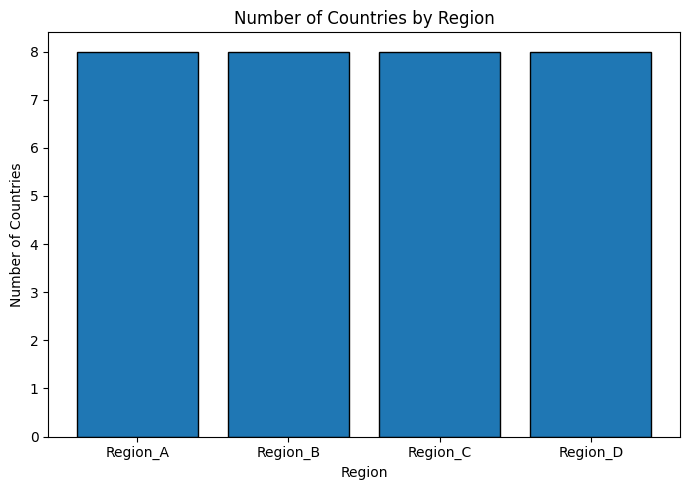

In [20]:
plt.figure(figsize=(7, 5))

plt.bar(
    region_counts.index,
    region_counts.values,
    edgecolor="black",
)

plt.title("Number of Countries by Region")
plt.xlabel("Region")
plt.ylabel("Number of Countries")
plt.tight_layout()
plt.show()

### Bar Chart of a Summary Statistic

A bar chart can also compare a summary statistic across categories.

Here we compare the **mean life expectancy** by region.

In [21]:
region_mean_life = (
    df.groupby("region")["life_expectancy"]
    .mean()
    .sort_index()
)

region_mean_life

region
Region_A    80.5000
Region_B    75.3500
Region_C    70.0375
Region_D    65.0125
Name: life_expectancy, dtype: float64

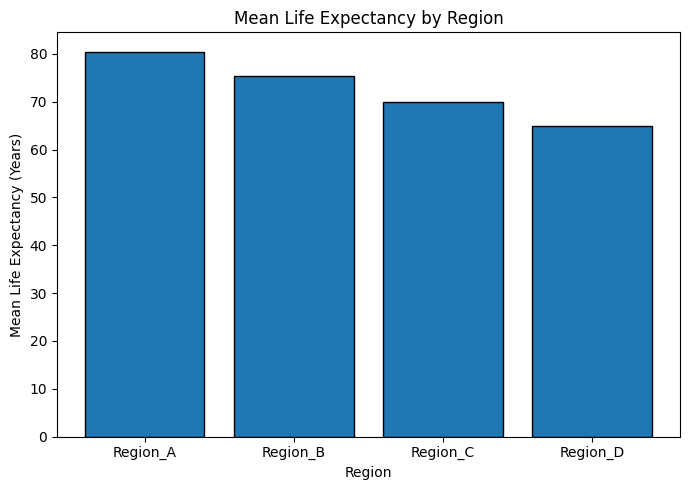

In [22]:
plt.figure(figsize=(7, 5))

plt.bar(
    region_mean_life.index,
    region_mean_life.values,
    edgecolor="black",
)

plt.title("Mean Life Expectancy by Region")
plt.xlabel("Region")
plt.ylabel("Mean Life Expectancy (Years)")
plt.tight_layout()
plt.show()

## 4. Scatter Plot — Exploring Relationships

A scatter plot displays two quantitative variables.

Each point represents one observation.

Scatter plots help us look for:

- positive relationships;
- negative relationships;
- weak or strong patterns;
- nonlinear patterns;
- unusual observations.

A visible relationship does **not** by itself establish causation.

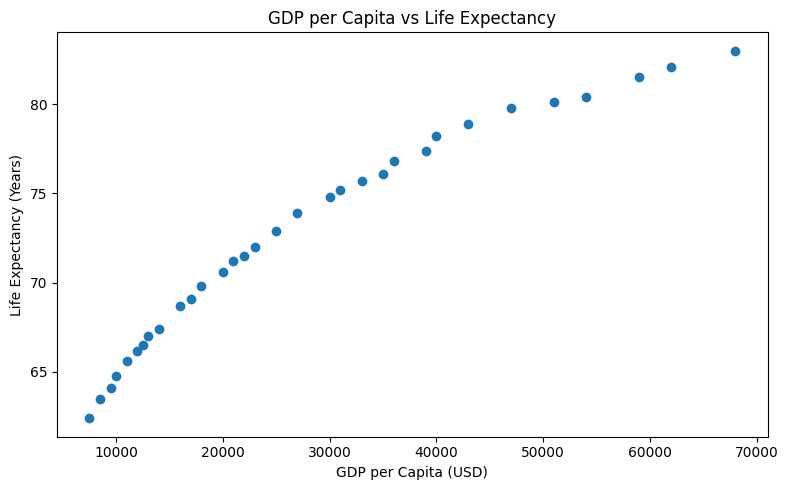

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["gdp_per_capita_usd"],
    df["life_expectancy"],
)

plt.title("GDP per Capita vs Life Expectancy")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Life Expectancy (Years)")
plt.tight_layout()
plt.show()

### Another Scatter Plot

The dataset was designed so that population size and median age also provide an interesting visual relationship to explore.

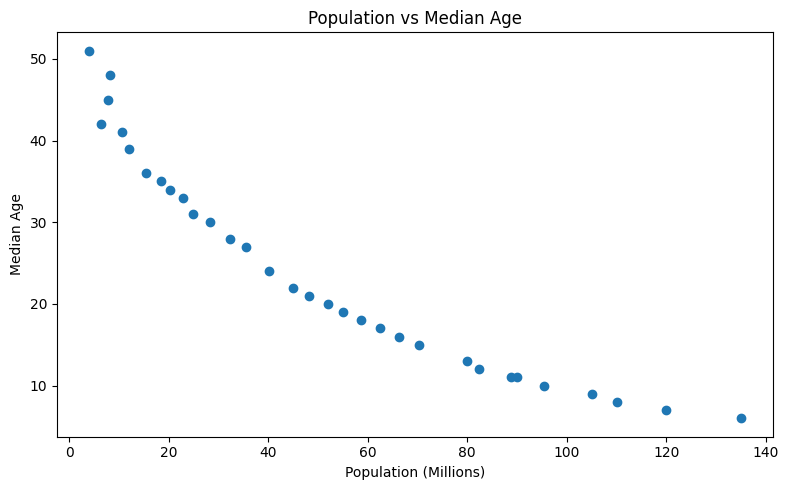

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["population_million"],
    df["median_age"],
)

plt.title("Population vs Median Age")
plt.xlabel("Population (Millions)")
plt.ylabel("Median Age")
plt.tight_layout()
plt.show()

## Visualize First, Calculate Next

A useful statistical habit is:

**Inspect the data → visualize the pattern → calculate statistics → interpret the result.**

A chart can suggest a pattern, but later chapters will give us numerical tools for measuring relationships.

For example, the scatter plot of GDP per capita and life expectancy appears to show a relationship. In Chapter 17, we will quantify relationships using **correlation analysis**.

## Common Visualization Mistakes

A graph can be technically correct and still be misleading.

Keep these principles in mind:

- label axes clearly;
- include units when relevant;
- choose a chart appropriate for the variable type;
- do not interpret correlation as causation;
- be cautious with arbitrary axis limits;
- remember that histogram appearance depends on bin selection;
- do not remove unusual observations merely because they make a graph look untidy.

## Exercises

### Exercise 1
Create a histogram of `population_million`. Describe its shape.

### Exercise 2
Change the number of bins in the life-expectancy histogram to 4 and then 16. How does the appearance change?

### Exercise 3
Create a box plot of `gdp_per_capita_usd` by region. What differences do you observe?

### Exercise 4
Create a bar chart showing the mean GDP per capita for each region.

### Exercise 5
Create a scatter plot of `median_age` and `life_expectancy`. Describe the direction of the apparent relationship.

### Exercise 6
For each situation below, choose a suitable chart and explain why:

1. Distribution of GDP per capita
2. Number of countries in each region
3. Relationship between GDP per capita and life expectancy
4. Comparison of life-expectancy distributions across regions

## Summary

In this chapter, you learned how to use:

- **Histograms** to examine quantitative distributions;
- **Box plots** to examine center, spread, and potential outliers;
- **Bar charts** to compare categorical groups;
- **Scatter plots** to explore relationships between quantitative variables.

The key lesson is that visualization is not decoration. It is part of statistical reasoning.

With descriptive statistics and visualization in place, the next part of the repository moves into **Probability**, beginning with Chapter 06: Probability Basics.